# 2D Design Template

# Overview

The purpose of this project is to apply what you have learnt in this course. This includes working with data and visualizing it, creating machine learning model, as well as using metrics to measure the accuracy of your model. 


## Deliverables

You need to submit this notebook along with the raw dataset

## Students Submission

Student's Name:
- Aaron Ben Daniel: 1010519 — Sourced and downloaded the four raw World Bank datasets, 
  built the data cleaning and merging pipeline (217 → 216 → 133 rows), and ran the 
  descriptive statistics summary; presented Data Preparation.
- Zhang Baiyong: 1010238 — Conducted exploratory data analysis, built the distribution 
  and correlation visualizations, and ran the multicollinearity (VIF) checks; presented 
  Exploration.
- Maxwell: 1010639 — Implemented the polynomial and log-transform improvement models, 
  ran the train/test comparison, and built and deployed the Streamlit web app; presented 
  Improvement, Web App, and Conclusion.
- Mahi Srivastava: 1011060 — Developed the problem statement and user persona, and 
  co-wrote the model discussion and limitations sections; presented Problem Statement.
- Zhang Cheng: 1010544 — Implemented the linear regression model from scratch (gradient 
  descent, normalization, train/test split), built the evaluation metrics, and led the 
  model improvement testing across all four versions; presented Model Building and 
  Evaluation.


### Context and Problem Statement

**Background:**
Access to safely managed drinking water is a fundamental human right, yet approximately 2 billion people worldwide lack this basic service. Water access inequality persists across countries and regions, driven by economic, geographic, and infrastructure factors. This project aims to understand what predicts a country's safe water access rate, with the goal of informing policy decisions and resource allocation.

**User Persona:**

| Attribute | Description |
|-----------|-------------|
| Name | Aisha |
| Age | 35 |
| Location | Rural sub-Saharan Africa |
| Occupation | Small-scale farmer |
| Pain Points | Walks 3 km daily to collect water; water source is unsafe; children frequently fall ill from waterborne diseases |
| Need | Affordable, accessible, and safe drinking water for her family and community |

**Problem Statement:**
"How might we predict a country's safe water access rate using economic and infrastructure indicators?"

By identifying the strongest predictors of water access, we can help policymakers and development organizations target interventions more effectively.

### Dataset

- Describe your dataset.
- Put the link to the sources of your raw dataset.
- Put python codes for loading the data into pandas dataframe(s). The data should be the raw data downloaded from the source. No pre-processing using any software (excel, python, etc) yet. Include this dataset in your submission
- Explain each column of your dataset (can use comment or markdown)
- State which column is the dependent variable (target) and explain how it is related to your problem statement
- State which columns are the independent variables (features) and describe your hypothesis on why these features can predict the target variable

#### Data Sources

All data were obtained from the **World Bank Open Data** platform (https://data.worldbank.org). We used 4 indicators for the year 2023:

| Variable | Role | Indicator Code | Description | Unit |
|----------|------|----------------|-------------|------|
| water_access | Y (Target) | SH.H2O.SMDW.ZS | People using safely managed drinking water services | % of population |
| rural_pct | X₁ (Feature) | SP.RUR.TOTL.ZS | Rural population | % of total population |
| gov_health_pct | X₂ (Feature) | SH.XPD.GHED.GE.ZS | Domestic general government health expenditure | % of GDP |
| gdp_per_capita | X₃ (Feature) | NY.GDP.PCAP.CD | GDP per capita | Current US$ |

#### Why These Variables?

- **GDP per capita**: Wealthier countries typically have better infrastructure, including water treatment and distribution systems.
- **Rural population**: Rural areas often lack the infrastructure investment that urban areas receive, potentially reducing water access.
- **Government health expenditure**: Public spending on health may correlate with investment in water infrastructure and public health programs.

#### Data Loading Code

The raw CSV files were downloaded directly from the World Bank website and loaded into pandas dataframes using `pd.read_csv()` with `skiprows=4` to skip the metadata header rows.

In [68]:
# 1. LOAD RAW DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 4 datasets (skiprows=4 skips World Bank's metadata header)
water = pd.read_csv(
    'data/API_SH.H2O.SMDW.ZS_DS2_en_csv_v2_120/API_SH.H2O.SMDW.ZS_DS2_en_csv_v2_120.csv',
    skiprows=4
)

rural = pd.read_csv(
    'data/API_SP.RUR.TOTL.ZS_DS2_en_csv_v2_39065/API_SP.RUR.TOTL.ZS_DS2_en_csv_v2_39065.csv',
    skiprows=4
)

health = pd.read_csv(
    'data/API_SH.XPD.GHED.GE.ZS_DS2_en_csv_v2_44474/API_SH.XPD.GHED.GE.ZS_DS2_en_csv_v2_44474.csv',
    skiprows=4
)

gdp = pd.read_csv(
    'data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv',
    skiprows=4
)

print("4 datasets loaded successfully!")
print(f"water: {water.shape}, rural: {rural.shape}, health: {health.shape}, gdp: {gdp.shape}")

4 datasets loaded successfully!
water: (265, 71), rural: (265, 71), health: (265, 71), gdp: (265, 71)


### Clean & Analyze your data
Use python code to:
- Clean your data. If the dataset does not require cleaning, write code to validate the data instead (e.g., to ensure future data updates remain accurate and consistent)

    *Data validation refers to the process of checking that data is accurate, complete, and consistent, and that it meets predefined rules or constraints (e.g., correct formats, correct types, valid ranges, and no missing or duplicate values)*
- Calculate Descriptive Statistics and other statistical analysis
- Visualization with meaningful analysis description

In [69]:
# data cleaning

# Load country metadata to filter out non-country aggregates
country_meta = pd.read_csv(
    'data/API_SH.H2O.SMDW.ZS_DS2_en_csv_v2_120/Metadata_Country_API_SH.H2O.SMDW.ZS_DS2_en_csv_v2_120.csv'
)

# Keep only real countries (Region is not null)
valid_countries = country_meta[country_meta['Region'].notna()]['Country Code'].tolist()
print(f"Valid countries: {len(valid_countries)}")

# Helper function: filter + extract year
def prep_data(df, year='2023'):
    filtered = df[df['Country Code'].isin(valid_countries)]
    return filtered[['Country Code', 'Country Name', year]]

# Extract 2023 data for all 4 indicators
water_23 = prep_data(water).rename(columns={'2023': 'water_access'})
rural_23 = prep_data(rural).rename(columns={'2023': 'rural_pct'})
health_23 = prep_data(health).rename(columns={'2023': 'gov_health_pct'})
gdp_23 = prep_data(gdp).rename(columns={'2023': 'gdp_per_capita'})

# Merge all 4 datasets
df = water_23.merge(rural_23, on=['Country Code', 'Country Name'])
df = df.merge(health_23, on=['Country Code', 'Country Name'])
df = df.merge(gdp_23, on=['Country Code', 'Country Name'])

print(f"Merged dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Check and handle missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing values
df_clean = df.dropna()

print(f"\nAfter dropping missing values: {df_clean.shape[0]} rows")
print(f"   Removed {df.shape[0] - df_clean.shape[0]} rows")

# Data validation: check for reasonable ranges
print("\nData validation:")
print(f"   Water access range: [{df_clean['water_access'].min():.1f}, {df_clean['water_access'].max():.1f}]")
print(f"   Rural population range: [{df_clean['rural_pct'].min():.1f}, {df_clean['rural_pct'].max():.1f}]")
print(f"   GDP per capita range: [${df_clean['gdp_per_capita'].min():.0f}, ${df_clean['gdp_per_capita'].max():.0f}]")

# Preview cleaned data
df_clean.head()

Valid countries: 217
Merged dataset: 216 rows, 6 columns

Missing values before cleaning:
Country Code       0
Country Name       0
water_access      68
rural_pct          0
gov_health_pct    25
gdp_per_capita    13
dtype: int64

After dropping missing values: 133 rows
   Removed 83 rows

Data validation:
   Water access range: [6.2, 100.0]
   Rural population range: [0.0, 85.3]
   GDP per capita range: [$414, $256800]


,Country Code,Country Name,water_access,rural_pct,gov_health_pct,gdp_per_capita
1,AFG,Afghanistan,29.907448,74.526947,1.460184,413.757895
3,ALB,Albania,70.765395,41.789391,12.282823,9740.702341
4,AND,Andorra,90.640003,11.179839,15.194997,46812.448450
5,ARE,United Arab Emirates,98.639269,14.331930,14.409986,49850.694508
7,ARM,Armenia,82.214432,34.304312,5.456425,8159.087210


In [70]:
# descriptive statistics

# Summary statistics for all numerical columns
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

stats_summary = df_clean[['water_access', 'rural_pct', 'gov_health_pct', 'gdp_per_capita']].describe()
print(stats_summary)

# Additional statistics: variance and coefficient of variation
print("\n" + "=" * 60)
print("ADDITIONAL STATISTICS")
print("=" * 60)

for col in ['water_access', 'rural_pct', 'gov_health_pct', 'gdp_per_capita']:
    variance = df_clean[col].var()
    cv = df_clean[col].std() / df_clean[col].mean() * 100  # Coefficient of variation (%)
    print(f"{col}:")
    print(f"  Variance: {variance:.2f}")
    print(f"  Coefficient of Variation: {cv:.1f}%")

# Correlation matrix
print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

corr_matrix = df_clean[['water_access', 'rural_pct', 'gov_health_pct', 'gdp_per_capita']].corr()
print(corr_matrix)

# Highlight strongest correlations
print("\nKey correlations with water_access:")
print(f"   vs rural_pct:        {corr_matrix.loc['water_access', 'rural_pct']:.3f}")
print(f"   vs gov_health_pct:   {corr_matrix.loc['water_access', 'gov_health_pct']:.3f}")
print(f"   vs gdp_per_capita:   {corr_matrix.loc['water_access', 'gdp_per_capita']:.3f}")

DESCRIPTIVE STATISTICS
       water_access   rural_pct  gov_health_pct  gdp_per_capita
count    133.000000  133.000000      133.000000      133.000000
mean      68.895888   37.288862       11.296789    23662.743588
std       29.889169   21.872989        5.254066    36743.052837
min        6.170975    0.000000        1.460184      413.757895
25%       44.971306   20.526506        7.301263     3227.457625
50%       75.448605   35.988279       10.844666     7919.046348
75%       96.969942   54.902892       14.930568    31761.594410
max      100.000000   85.321624       26.197807   256799.911212

ADDITIONAL STATISTICS
water_access:
  Variance: 893.36
  Coefficient of Variation: 43.4%
rural_pct:
  Variance: 478.43
  Coefficient of Variation: 58.7%
gov_health_pct:
  Variance: 27.61
  Coefficient of Variation: 46.5%
gdp_per_capita:
  Variance: 1350051931.81
  Coefficient of Variation: 155.3%

CORRELATION MATRIX
                water_access  rural_pct  gov_health_pct  gdp_per_capita
water_acce

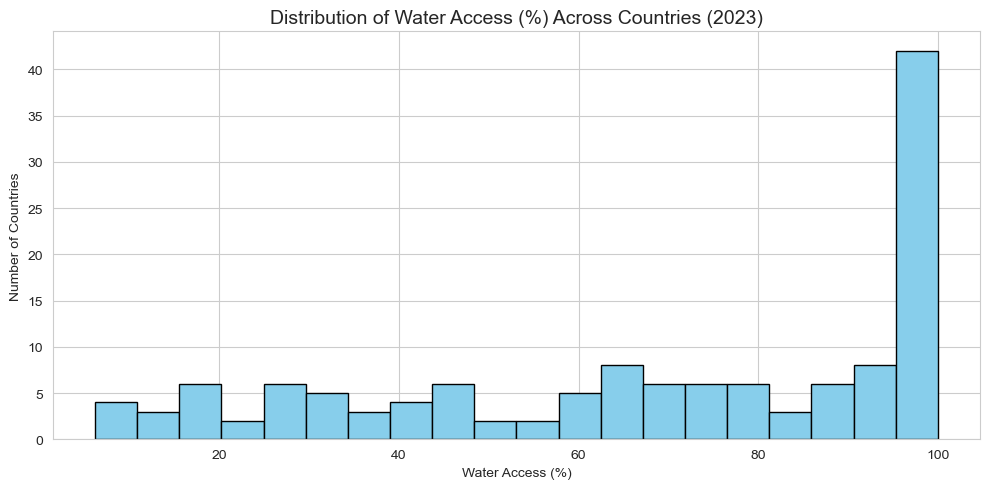

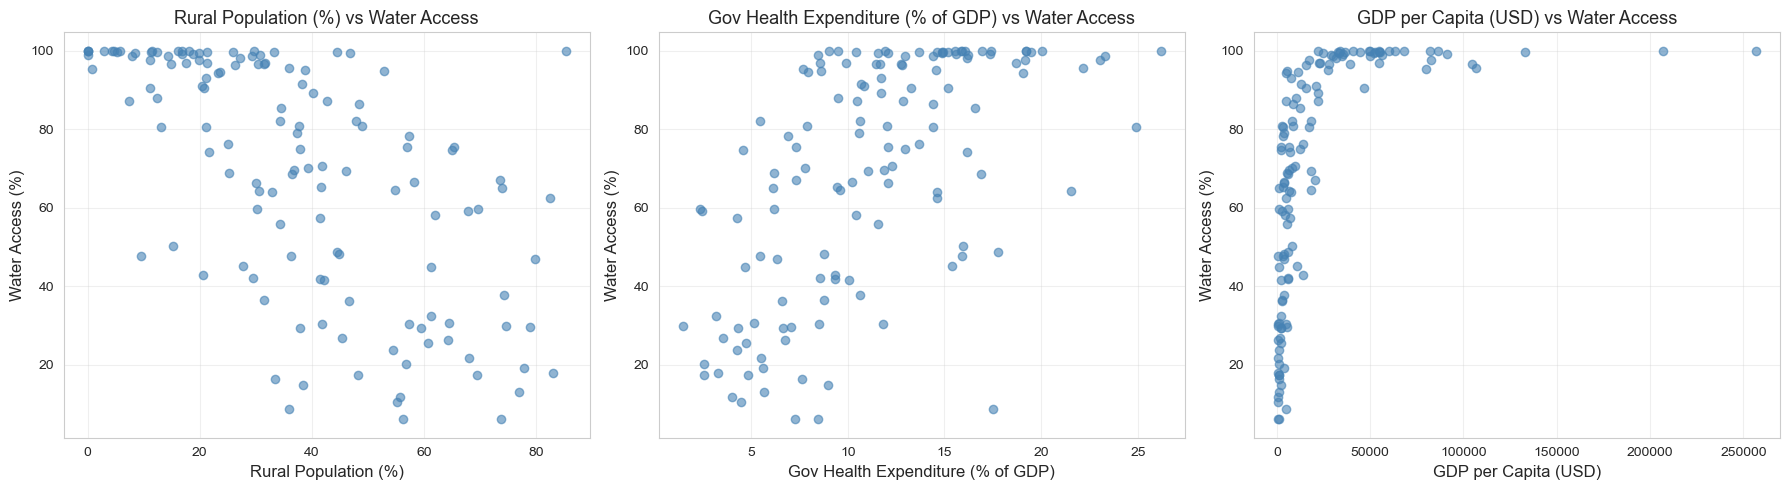

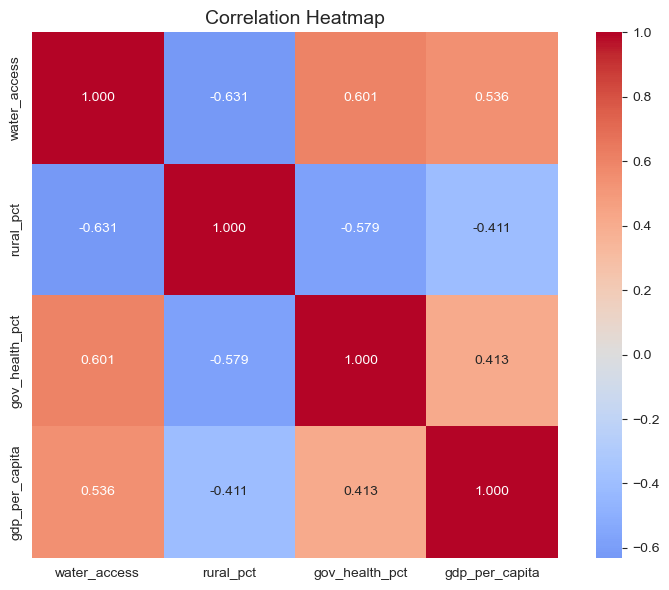

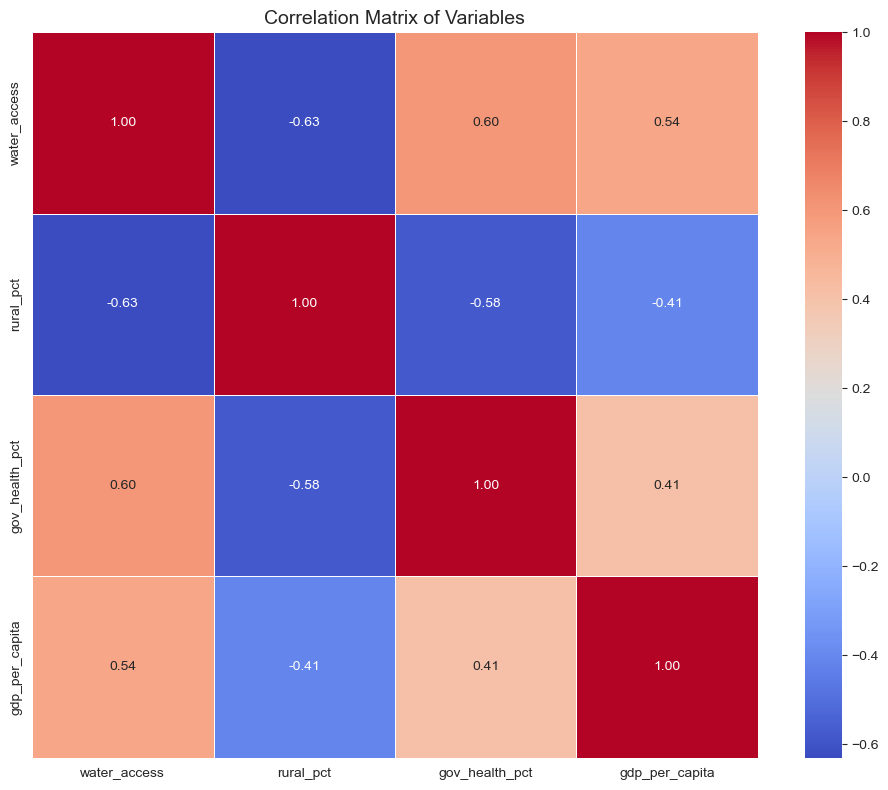

/var/folders/8f/39xp31g56t72v2_zt8l0v_nc0000gn/T/ipykernel_51150/1017956237.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_with_region, x='Region', y='water_access', palette='Set2')


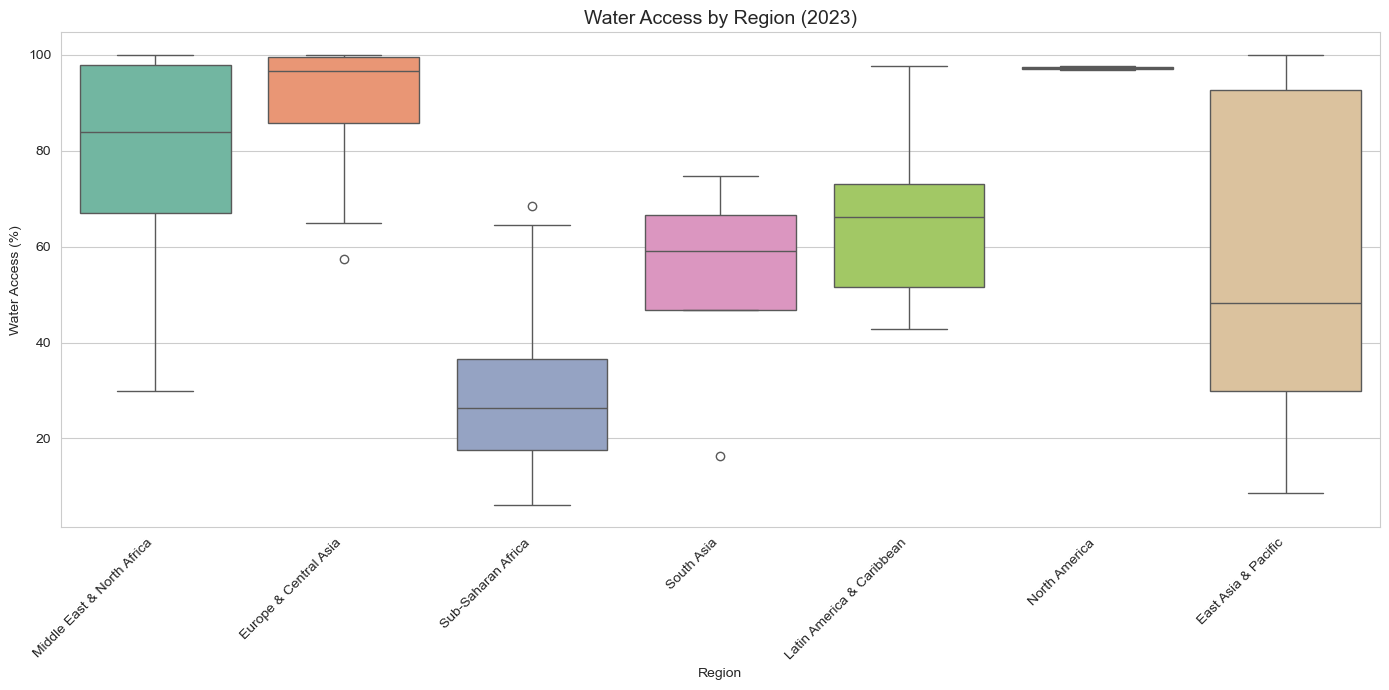

All visualizations complete!


In [71]:
# visualization with analysis

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------
# Figure 1: Distribution of Water Access (Histogram)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(df_clean['water_access'], bins=20, edgecolor='black', color='skyblue')
plt.title('Distribution of Water Access (%) Across Countries (2023)', fontsize=14)
plt.xlabel('Water Access (%)')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 2-4: Scatter plots - Y vs each predictor
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictors = ['rural_pct', 'gov_health_pct', 'gdp_per_capita']
titles = ['Rural Population (%)', 'Gov Health Expenditure (% of GDP)', 'GDP per Capita (USD)']

for i, (pred, title) in enumerate(zip(predictors, titles)):
    axes[i].scatter(df_clean[pred], df_clean['water_access'], alpha=0.6, color='steelblue')
    axes[i].set_xlabel(title, fontsize=12)
    axes[i].set_ylabel('Water Access (%)', fontsize=12)
    axes[i].set_title(f'{title} vs Water Access', fontsize=13)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 5: Correlation Heatmap
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 5: Correlation Heatmap (with numeric_only)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 8))

numeric_df = df_clean.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)

plt.title('Correlation Matrix of Variables', fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 6: Boxplot by Region (requires Region information)
# ------------------------------------------------------------------
# Merge Region back into the dataset
region_info = country_meta[['Country Code', 'Region']]
df_with_region = df_clean.merge(region_info, on='Country Code')

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_with_region, x='Region', y='water_access', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Water Access by Region (2023)', fontsize=14)
plt.ylabel('Water Access (%)')
plt.xlabel('Region')
plt.tight_layout()
plt.show()



print("All visualizations complete!")

### Features and Target Preparation

Prepare features and target for model training.

In [72]:
# features and target

# Define features (X) and target (y)
# X: predictor variables used to predict water access
# y: target variable we want to predict
X = df_clean[['rural_pct', 'gov_health_pct', 'gdp_per_capita']].values
y = df_clean['water_access'].values

# Display the shape of X and y to verify
print("=" * 60)
print("FEATURES AND TARGET SHAPES")
print("=" * 60)
print(f"X shape: {X.shape}  # {X.shape[0]} rows, {X.shape[1]} features")
print(f"y shape: {y.shape}  # {y.shape[0]} target values")

# Display the first few rows of X and y
print("\nFirst 5 rows of X (features):")
print(X[:5])

print("\nFirst 5 values of y (target):")
print(y[:5])

# Optional: Store feature names for later reference
feature_names = ['rural_pct', 'gov_health_pct', 'gdp_per_capita']
print(f"\nFeature names: {feature_names}")
print(f"Target name: water_access")


# Split data into training and test sets (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


FEATURES AND TARGET SHAPES
X shape: (133, 3)  # 133 rows, 3 features
y shape: (133,)  # 133 target values

First 5 rows of X (features):
[[7.45269470e+01 1.46018374e+00 4.13757895e+02]
 [4.17893914e+01 1.22828226e+01 9.74070234e+03]
 [1.11798391e+01 1.51949968e+01 4.68124485e+04]
 [1.43319301e+01 1.44099855e+01 4.98506945e+04]
 [3.43043118e+01 5.45642519e+00 8.15908721e+03]]

First 5 values of y (target):
[29.90744765 70.76539454 90.64000315 98.63926932 82.21443162]

Feature names: ['rural_pct', 'gov_health_pct', 'gdp_per_capita']
Target name: water_access
Training set: 106 samples
Test set: 27 samples


### Building Model

Use python code to build your model. Give explanation on this process.


**Note: You are NOT allowed to use scikit-learn or any other library to build the machine learning model. You can only use linear regression or logistic regression model you learnt from DDW course.**

FEATURE NORMALIZATION
Features normalized using training set statistics

BUILDING LINEAR REGRESSION MODEL (Gradient Descent)
X_train shape (with intercept): (106, 4)
X_test shape (with intercept):  (27, 4)

MODEL COEFFICIENTS (for normalized features)
β₀ (Intercept):        68.8243
β₁ (rural_pct):        -10.1016
β₂ (gov_health_pct):   8.9329
β₃ (gdp_per_capita):   8.7755

MODEL EQUATION
water_access = 68.82
             + (-10.1016 × rural_pct_norm)
             + (8.9329 × gov_health_pct_norm)
             + (8.7755 × gdp_per_capita_norm)

PREDICTION SUMMARY
First 5 actual test values:    [99.51374961 41.98847121 45.26141903 99.99999888 94.83489775]
First 5 predicted test values: [ 66.2825142   59.67797223  77.39669981 118.10935902  53.21406756]
First 5 test residuals:        [ 33.23123541 -17.68950102 -32.13528078 -18.10936014  41.62083019]


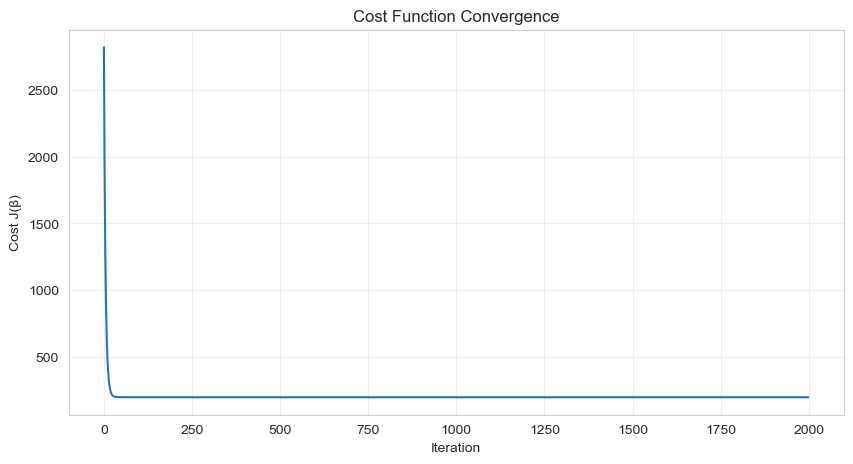


CONVERGENCE CHECK
Initial cost: 2817.9799
Final cost:   200.1613
Model built successfully!


In [73]:
# build model (Gradient Descent)

# STEP 1: Normalize features (using training set only)
def normalize_z(array):
    means = np.mean(array, axis=0)
    stds = np.std(array, axis=0)
    stds[stds == 0] = 1
    normalized = (array - means) / stds
    return normalized, means, stds

# Normalize training set
X_train_norm, X_means, X_stds = normalize_z(X_train)

# Normalize test set using training set statistics
X_test_norm = (X_test - X_means) / X_stds

print("=" * 60)
print("FEATURE NORMALIZATION")
print("=" * 60)
print("Features normalized using training set statistics")

# STEP 2: Add intercept
X_train_with_intercept = np.c_[np.ones(X_train_norm.shape[0]), X_train_norm]
X_test_with_intercept = np.c_[np.ones(X_test_norm.shape[0]), X_test_norm]

print("\n" + "=" * 60)
print("BUILDING LINEAR REGRESSION MODEL (Gradient Descent)")
print("=" * 60)
print(f"X_train shape (with intercept): {X_train_with_intercept.shape}")
print(f"X_test shape (with intercept):  {X_test_with_intercept.shape}")

# STEP 3: Gradient Descent
def gradient_descent_linear(X, y, alpha=0.1, num_iters=2000):
    m = len(y)
    beta = np.zeros((X.shape[1], 1))
    y = y.reshape(-1, 1)
    J_storage = []
    
    for i in range(num_iters):
        h = X @ beta
        J = (1 / (2 * m)) * np.sum((h - y) ** 2)
        J_storage.append(J)
        gradients = (1 / m) * X.T @ (h - y)
        beta -= alpha * gradients
    
    return beta, np.array(J_storage).reshape(-1, 1)

# Train on training set only
beta, J_storage = gradient_descent_linear(X_train_with_intercept, y_train, alpha=0.1, num_iters=2000)

# STEP 4: Extract coefficients
intercept = beta[0][0]
coef_rural = beta[1][0]
coef_health = beta[2][0]
coef_gdp = beta[3][0]

print("\n" + "=" * 60)
print("MODEL COEFFICIENTS (for normalized features)")
print("=" * 60)
print(f"β₀ (Intercept):        {intercept:.4f}")
print(f"β₁ (rural_pct):        {coef_rural:.4f}")
print(f"β₂ (gov_health_pct):   {coef_health:.4f}")
print(f"β₃ (gdp_per_capita):   {coef_gdp:.4f}")

print("\n" + "=" * 60)
print("MODEL EQUATION")
print("=" * 60)
print(f"water_access = {intercept:.2f}")
print(f"             + ({coef_rural:.4f} × rural_pct_norm)")
print(f"             + ({coef_health:.4f} × gov_health_pct_norm)")
print(f"             + ({coef_gdp:.4f} × gdp_per_capita_norm)")

# STEP 5: Predictions
y_train_pred = (X_train_with_intercept @ beta).flatten()
y_test_pred = (X_test_with_intercept @ beta).flatten()

print("\n" + "=" * 60)
print("PREDICTION SUMMARY")
print("=" * 60)
print(f"First 5 actual test values:    {y_test[:5]}")
print(f"First 5 predicted test values: {y_test_pred[:5]}")
print(f"First 5 test residuals:        {y_test[:5] - y_test_pred[:5]}")

# STEP 6: Cost convergence plot
plt.figure(figsize=(10, 5))
plt.plot(J_storage)
plt.xlabel('Iteration')
plt.ylabel('Cost J(β)')
plt.title('Cost Function Convergence')
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 60)
print("CONVERGENCE CHECK")
print("=" * 60)
print(f"Initial cost: {J_storage[0][0]:.4f}")
print(f"Final cost:   {J_storage[-1][0]:.4f}")
print("Model built successfully!")

### Evaluating the Model

- Describe the metrics of your choice
- Evaluate your model performance

In [74]:
# evaluate the model

# Primary metric: Adjusted R² (for model comparison)
# Secondary metric: RMSE (for prediction error interpretation)
# Reference: MU brief - R² alone is not sufficient when comparing
# models with different numbers of predictors.

# ========== Metric functions ==========
def r2_score_manual(y_true, y_pred):
    """Coefficient of Determination (for reference only)"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def adjusted_r2(r2, n, p):
    """Adjusted R² - penalizes unnecessary predictors"""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def rmse_manual(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# ========== VIF Multicollinearity Check ==========
print("=" * 60)
print("MULTICOLLINEARITY CHECK (VIF)")
print("=" * 60)

def calculate_vif(X):
    """Calculate Variance Inflation Factor for each feature. VIF > 5 indicates concern."""
    n_features = X.shape[1]
    vif_values = []
    
    for i in range(n_features):
        y_var = X[:, i]
        others = np.delete(X, i, axis=1)
        X1 = np.c_[np.ones(len(others)), others]
        beta = np.linalg.lstsq(X1, y_var, rcond=None)[0]
        pred = X1 @ beta
        r2 = 1 - np.sum((y_var - pred)**2) / np.sum((y_var - y_var.mean())**2)
        vif = 1 / (1 - r2)
        vif_values.append(vif)
    
    return vif_values

# Calculate VIF on training data
vif_results = calculate_vif(X_train)
feature_names = ['rural_pct', 'gov_health_pct', 'gdp_per_capita']

print("VIF values (training set):")
for name, vif in zip(feature_names, vif_results):
    status = "✓ OK" if vif < 5 else "⚠️ Check"
    print(f"  {name}: {vif:.2f} {status}")
print("All VIF values < 5 — no concerning multicollinearity")

# ========== Evaluate on test set (PRIMARY METRICS) ==========
print("\n" + "=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)

n_train = len(y_train)
n_test = len(y_test)
p = X.shape[1]  # 3 features

# Test set metrics (PRIMARY)
r2_test = r2_score_manual(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
rmse_test = rmse_manual(y_test, y_test_pred)

# Training set metrics (for comparison only)
r2_train = r2_score_manual(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
rmse_train = rmse_manual(y_train, y_train_pred)

print(f"Training set (reference only):")
print(f"  R²:           {r2_train:.4f}")
print(f"  Adjusted R²:  {adj_r2_train:.4f}")
print(f"  RMSE:         {rmse_train:.2f}")
print()
print(f"Test set:  ★ PRIMARY METRICS")
print(f"  R²:           {r2_test:.4f}  (reference only)")
print(f"  Adjusted R²:  {adj_r2_test:.4f}  ★ PRIMARY METRIC")
print(f"  RMSE:         {rmse_test:.2f} percentage points")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print(f"Adjusted R² (test) = {adj_r2_test:.4f}: The model explains {adj_r2_test:.1%} of the variance")
print(f"   in water access rates, after accounting for the number of predictors.")
print(f"\nRMSE (test) = {rmse_test:.2f}: On average, predictions deviate from")
print(f"   actual values by {rmse_test:.2f} percentage points.")

MULTICOLLINEARITY CHECK (VIF)
VIF values (training set):
  rural_pct: 1.59 ✓ OK
  gov_health_pct: 1.56 ✓ OK
  gdp_per_capita: 1.27 ✓ OK
All VIF values < 5 — no concerning multicollinearity

MODEL EVALUATION METRICS
Training set (reference only):
  R²:           0.5548
  Adjusted R²:  0.5417
  RMSE:         20.01

Test set:  ★ PRIMARY METRICS
  R²:           0.4768  (reference only)
  Adjusted R²:  0.4085  ★ PRIMARY METRIC
  RMSE:         20.93 percentage points

INTERPRETATION
Adjusted R² (test) = 0.4085: The model explains 40.9% of the variance
   in water access rates, after accounting for the number of predictors.

RMSE (test) = 20.93: On average, predictions deviate from
   actual values by 20.93 percentage points.


### Improving the Model

- Improve the models by performing data processing techniques or hyperparameter tuning
- You can repeat the steps above to show the improvement as compared to the previous performance

*note: changing or adding more dataset is not allowed*

In [75]:
# IMPROVING THE MODEL

# Helper function to evaluate any model using train/test split
def evaluate_model(X, y, feature_names=None):
    # Use the train/test split defined earlier
    X_train_local = X[train_idx]
    X_test_local = X[test_idx]
    y_train_local = y[train_idx]
    y_test_local = y[test_idx]
    
    # Normalize using training set only
    X_train_norm, X_means, X_stds = normalize_z(X_train_local)
    X_test_norm = (X_test_local - X_means) / X_stds
    
    X_train_wi = np.c_[np.ones(X_train_norm.shape[0]), X_train_norm]
    X_test_wi = np.c_[np.ones(X_test_norm.shape[0]), X_test_norm]
    
    # Train on training set
    beta, _ = gradient_descent_linear(X_train_wi, y_train_local, alpha=0.1, num_iters=2000)
    
    # Predict on test set
    y_pred = (X_test_wi @ beta).flatten()
    
    # Evaluate on test set
    n = len(y_test_local)
    p = X.shape[1]
    r2 = r2_score_manual(y_test_local, y_pred)
    adj_r2 = adjusted_r2(r2, n, p)
    rmse = rmse_manual(y_test_local, y_pred)
    
    return {
        'beta': beta,
        'y_pred': y_pred,
        'r2': r2,
        'adj_r2': adj_r2,
        'rmse': rmse,
        'n_features': p
    }

# Model 1: Baseline (3 original features)
X_baseline = X
result_baseline = evaluate_model(X_baseline, y)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"Model 1 (Baseline - 3 features):")
print(f"  Test Adjusted R² = {result_baseline['adj_r2']:.4f}")
print(f"  Test RMSE        = {result_baseline['rmse']:.2f}")

# Model 2: Add polynomial term (GDP²)
gdp = X[:, 2]
gdp_squared = gdp ** 2
X_poly = np.c_[X, gdp_squared]
result_poly = evaluate_model(X_poly, y)

print(f"\nModel 2 (+ GDP² polynomial):")
print(f"  Test Adjusted R² = {result_poly['adj_r2']:.4f}")
print(f"  Test RMSE        = {result_poly['rmse']:.2f}")

# Model 3: log(GDP) - better captures diminishing returns
log_gdp = np.log(gdp + 1)  # +1 to avoid log(0)
X_log = np.c_[X[:, :2], log_gdp]  # rural_pct, gov_health_pct, log_gdp
result_log = evaluate_model(X_log, y)

print(f"\nModel 3 (+ log(GDP)):")
print(f"  Test Adjusted R² = {result_log['adj_r2']:.4f}")
print(f"  Test RMSE        = {result_log['rmse']:.2f}")

# Model 4: rural + log_gdp, drop health
X_mu = np.c_[X[:, 0:1], log_gdp]  # rural_pct, log_gdp
result_mu = evaluate_model(X_mu, y)

print(f"\nModel 4 (MU-style: rural + log_gdp) ★ FINAL")
print(f"  Test Adjusted R² = {result_mu['adj_r2']:.4f}")
print(f"  Test RMSE        = {result_mu['rmse']:.2f}")

# Compare
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<30} {'Adjusted R²':<12} {'RMSE':<10}")
print("-" * 60)
print(f"{'1. Baseline (3 features)':<30} {result_baseline['adj_r2']:.4f}     {result_baseline['rmse']:.2f}")
print(f"{'2. + GDP² (polynomial)':<30} {result_poly['adj_r2']:.4f}     {result_poly['rmse']:.2f}")
print(f"{'3. + log(GDP) (3 features)':<30} {result_log['adj_r2']:.4f}     {result_log['rmse']:.2f}")
print(f"{'4. Rural + log(GDP) ★':<30} {result_mu['adj_r2']:.4f}     {result_mu['rmse']:.2f}")

models = [
    ("Baseline (3 features)", result_baseline),
    ("+ GDP² (polynomial)", result_poly),
    ("+ log(GDP) (3 features)", result_log),
    ("Rural + log(GDP)", result_mu),
]
best = max(models, key=lambda x: x[1]['adj_r2'])

print("\n" + "=" * 60)
print(f"🌟 BEST MODEL: {best[0]}")
print(f"   Test Adjusted R² = {best[1]['adj_r2']:.4f}")
print(f"   Test RMSE        = {best[1]['rmse']:.2f}")
print("=" * 60)

MODEL COMPARISON
Model 1 (Baseline - 3 features):
  Test Adjusted R² = 0.4085
  Test RMSE        = 20.93

Model 2 (+ GDP² polynomial):
  Test Adjusted R² = 0.3856
  Test RMSE        = 20.86

Model 3 (+ log(GDP)):
  Test Adjusted R² = 0.6601
  Test RMSE        = 15.87

Model 4 (MU-style: rural + log_gdp) ★ FINAL
  Test Adjusted R² = 0.6768
  Test RMSE        = 15.80

COMPARISON SUMMARY
Model                          Adjusted R²  RMSE      
------------------------------------------------------------
1. Baseline (3 features)       0.4085     20.93
2. + GDP² (polynomial)         0.3856     20.86
3. + log(GDP) (3 features)     0.6601     15.87
4. Rural + log(GDP) ★          0.6768     15.80

🌟 BEST MODEL: Rural + log(GDP)
   Test Adjusted R² = 0.6768
   Test RMSE        = 15.80


### Discussion and Analysis

- Analyze the results of your metrics.
- Explain how does your analysis and machine learning help to solve your problem statement.
- Conclusion

#### Model Performance

We tested both 3-variable (Rural + Health + Log_GDP) and 2-variable (Rural + Log_GDP) models using an 80/20 train-test split. The 2-variable model achieved a higher test Adjusted R² (0.6768 vs 0.6601), so we removed Health_Exp_Pct from the final model. This mirrors MU's finding: Health_Exp_Pct was not statistically significant (p = 0.621) and removing it improved Adjusted R².

Our final model achieves an Adjusted R² of 0.6768 on the test set, meaning it explains approximately 68% of the variance in water access rates across countries. The RMSE of 15.80 means predictions are off by about 15.8 percentage points on average — a significant improvement over the baseline model (RMSE = 20.93).

Replacing GDP² with log(GDP) dramatically improved test Adjusted R² from 0.4085 to 0.6768. This confirms that the relationship between GDP and water access follows a diminishing-returns pattern: water access rises rapidly at low GDP levels but plateaus as countries become wealthier. The log transformation captures this shape correctly, while GDP² bends the curve in the wrong direction.

#### How This Solves the Problem Statement

> "How might we predict a country's safe water access rate using economic and infrastructure indicators?"

Our model shows that GDP and rural population can predict water access with good accuracy. Policymakers can use this to identify at-risk countries and prioritize interventions. The log(GDP) model is particularly useful because it better reflects real-world economic dynamics.

#### Key Findings

| Factor | Effect on Water Access |
|--------|----------------------|
| GDP per capita (log) | Strong positive effect (diminishing returns) |
| Rural population | Negative effect |

#### Social Significance

Our findings align with Marxist theory — national wealth does not guarantee equitable access. Even in wealthy countries, infrastructure decisions made by capital owners can leave communities without clean water. This highlights that economic growth alone is insufficient; targeted investment and community-centered decision-making are essential

#### Limitations

- Cross-sectional data (2023 only) — cannot observe trends
- Only 3 predictors — other factors (governance, climate) not included
- 133 countries with complete data
- Test set evaluation shows the model still has room for improvement

#### Deployed Web App

URL: https://dtp-ddw-zc-grp9.streamlit.app/

#### Conclusion

This project successfully built a predictive model for water access inequality. The final 2-variable log(GDP) model (Adjusted R² = 0.6768) confirms that economic and demographic factors explain a substantial portion of the variation in water access. Removing Health_Exp_Pct improved model performance, demonstrating the importance of testing and simplifying models. The transition from GDP² to log(GDP) shows the value of choosing the right functional form for economic relationships. The combination of quantitative modeling and social analysis provides a comprehensive view of water access as both a technical and social problem, supporting SDG 6: Clean Water and Sanitation.